In [15]:
# import libraries
import json, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

n_threads = os.cpu_count() or 4
torch.set_num_threads(n_threads)

PROJECT_ROOT = Path(r"C:\Users\Admin\lungprints")
RES_DIR      = PROJECT_ROOT / "results"
FIG_DIR      = RES_DIR / "figures"
MODEL_DIR    = RES_DIR / "models"
GRADCAM_DIR  = FIG_DIR / "gradcam"
GRADCAM_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cpu")
print("Device:", DEVICE)

Device: cpu


In [16]:
# configure and verify checkpoints
MODEL_NAME = "densenet121"
IMG_SIZE   = 96        # must match Notebook 04

# Confirm the files we need exist
ckpt_path = MODEL_DIR / f"{MODEL_NAME}_best.pt"
sel_path  = RES_DIR / "04_best_model_selection.json"

print("Checkpoint exists:", ckpt_path.exists(), "|", ckpt_path)
print("Selection exists: ", sel_path.exists(),  "|", sel_path)

# Load selection if present, otherwise read metrics from checkpoint
if sel_path.exists():
    with open(sel_path) as f:
        selection = json.load(f)
    print("\nRecorded best model:", selection["best_model"])
    print("Val metrics:", {k: round(v, 4) for k, v in selection["val_metrics"].items()})
else:
    selection = None
    print("\nNo selection file — will read metrics from checkpoint.")

Checkpoint exists: True | C:\Users\Admin\lungprints\results\models\densenet121_best.pt
Selection exists:  True | C:\Users\Admin\lungprints\results\04_best_model_selection.json

Recorded best model: densenet121
Val metrics: {'accuracy': 0.9771, 'precision': 0.9922, 'recall': 0.9768, 'f1': 0.9844, 'roc_auc': 0.9972, 'pr_auc': 0.999}


In [17]:
# load densenet121 model and checkpoint
# Rebuild architecture (no pretrained weights — we load our own)
model = models.densenet121(weights=None)
model.classifier = nn.Linear(model.classifier.in_features, 2)

ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model = model.to(DEVICE)
model.eval()

print("Loaded DenseNet121 from epoch", ckpt["epoch"])
print("Val metrics at best epoch:",
      {k: round(v, 4) for k, v in ckpt["val_metrics"].items()})

Loaded DenseNet121 from epoch 11
Val metrics at best epoch: {'accuracy': 0.9771, 'precision': 0.9922, 'recall': 0.9768, 'f1': 0.9844, 'roc_auc': 0.9972, 'pr_auc': 0.999}


In [18]:
# target layer for Grad-CAM
# DenseNet121: features.norm5's output is modified inplace by the ReLU
# in the model's forward(), which breaks backward hooks.
# Use features.denseblock4 instead — real tensor, not modified inplace.
target_layer = model.features.denseblock4
print("Target layer:", target_layer.__class__.__name__)

Target layer: _DenseBlock


In [ ]:
# grad cam
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inp, out):
            self.activations = out
            out.retain_grad()   # keep grad on this tensor
        self.target_layer.register_forward_hook(forward_hook)

    def generate(self, img_tensor, class_idx=1):
        """img_tensor: (1,3,H,W). class_idx=1 = PNEUMONIA."""
        self.model.zero_grad()
        self.activations = None

        logits = self.model(img_tensor)
        score = logits[0, class_idx]
        score.backward(retain_graph=True)

        # activations and .grad are shape (1, C, h, w)
        acts  = self.activations            
        grads = self.activations.grad       

        weights = grads.mean(dim=(2, 3), keepdim=True)  
        cam = (weights * acts).sum(dim=1, keepdim=True)  
        cam = F.relu(cam)[0, 0]                          

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.detach().cpu().numpy(), \
               torch.softmax(logits, dim=1)[0].detach().cpu().numpy()

gradcam = GradCAM(model, target_layer)
print("Grad-CAM ready on DenseNet121 (target: denseblock4).")

Grad-CAM ready on DenseNet121 (target: denseblock4).


In [20]:
# validation loader
with open(RES_DIR / "splits.json") as f:
    S = json.load(f)

val_files, val_labels = S["val_files"], S["val_labels"]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ChestXrayDataset(Dataset):
    def __init__(self, files, labels, transform=None):
        self.files = list(files); self.labels = list(labels); self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("L")
        if self.transform: img = self.transform(img)
        return img, self.labels[idx], str(self.files[idx])

val_ds = ChestXrayDataset(val_files, val_labels, eval_tfms)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
print("Val samples:", len(val_ds))

Val samples: 1047


In [ ]:
# predict on validation (find TP/TN/FP/FN)
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inp, out):
            self.activations = out
            if out.requires_grad:         
                out.retain_grad()
        self.target_layer.register_forward_hook(forward_hook)

    def generate(self, img_tensor, class_idx=1):
        """img_tensor: (1,3,H,W). class_idx=1 = PNEUMONIA."""
        self.model.zero_grad()
        self.activations = None

        logits = self.model(img_tensor)
        score = logits[0, class_idx]
        score.backward(retain_graph=True)

        acts  = self.activations
        grads = self.activations.grad
        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)[0, 0]

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.detach().cpu().numpy(), \
               torch.softmax(logits, dim=1)[0].detach().cpu().numpy()

gradcam = GradCAM(model, target_layer)
print("Grad-CAM ready on DenseNet121 (target: denseblock4).")

Grad-CAM ready on DenseNet121 (target: denseblock4).


In [24]:
# overlay helper
def overlay_cam(pil_img, cam, alpha=0.4, cmap="jet"):
    img = np.array(pil_img.resize((IMG_SIZE, IMG_SIZE))).astype(np.float32) / 255.0
    img_rgb = np.stack([img]*3, axis=-1)

    cam_resized = np.array(
        Image.fromarray((cam * 255).astype(np.uint8))
             .resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    ) / 255.0

    heat = plt.get_cmap(cmap)(cam_resized)[..., :3]
    overlay = (1 - alpha) * img_rgb + alpha * heat
    return img_rgb, heat, np.clip(overlay, 0, 1)

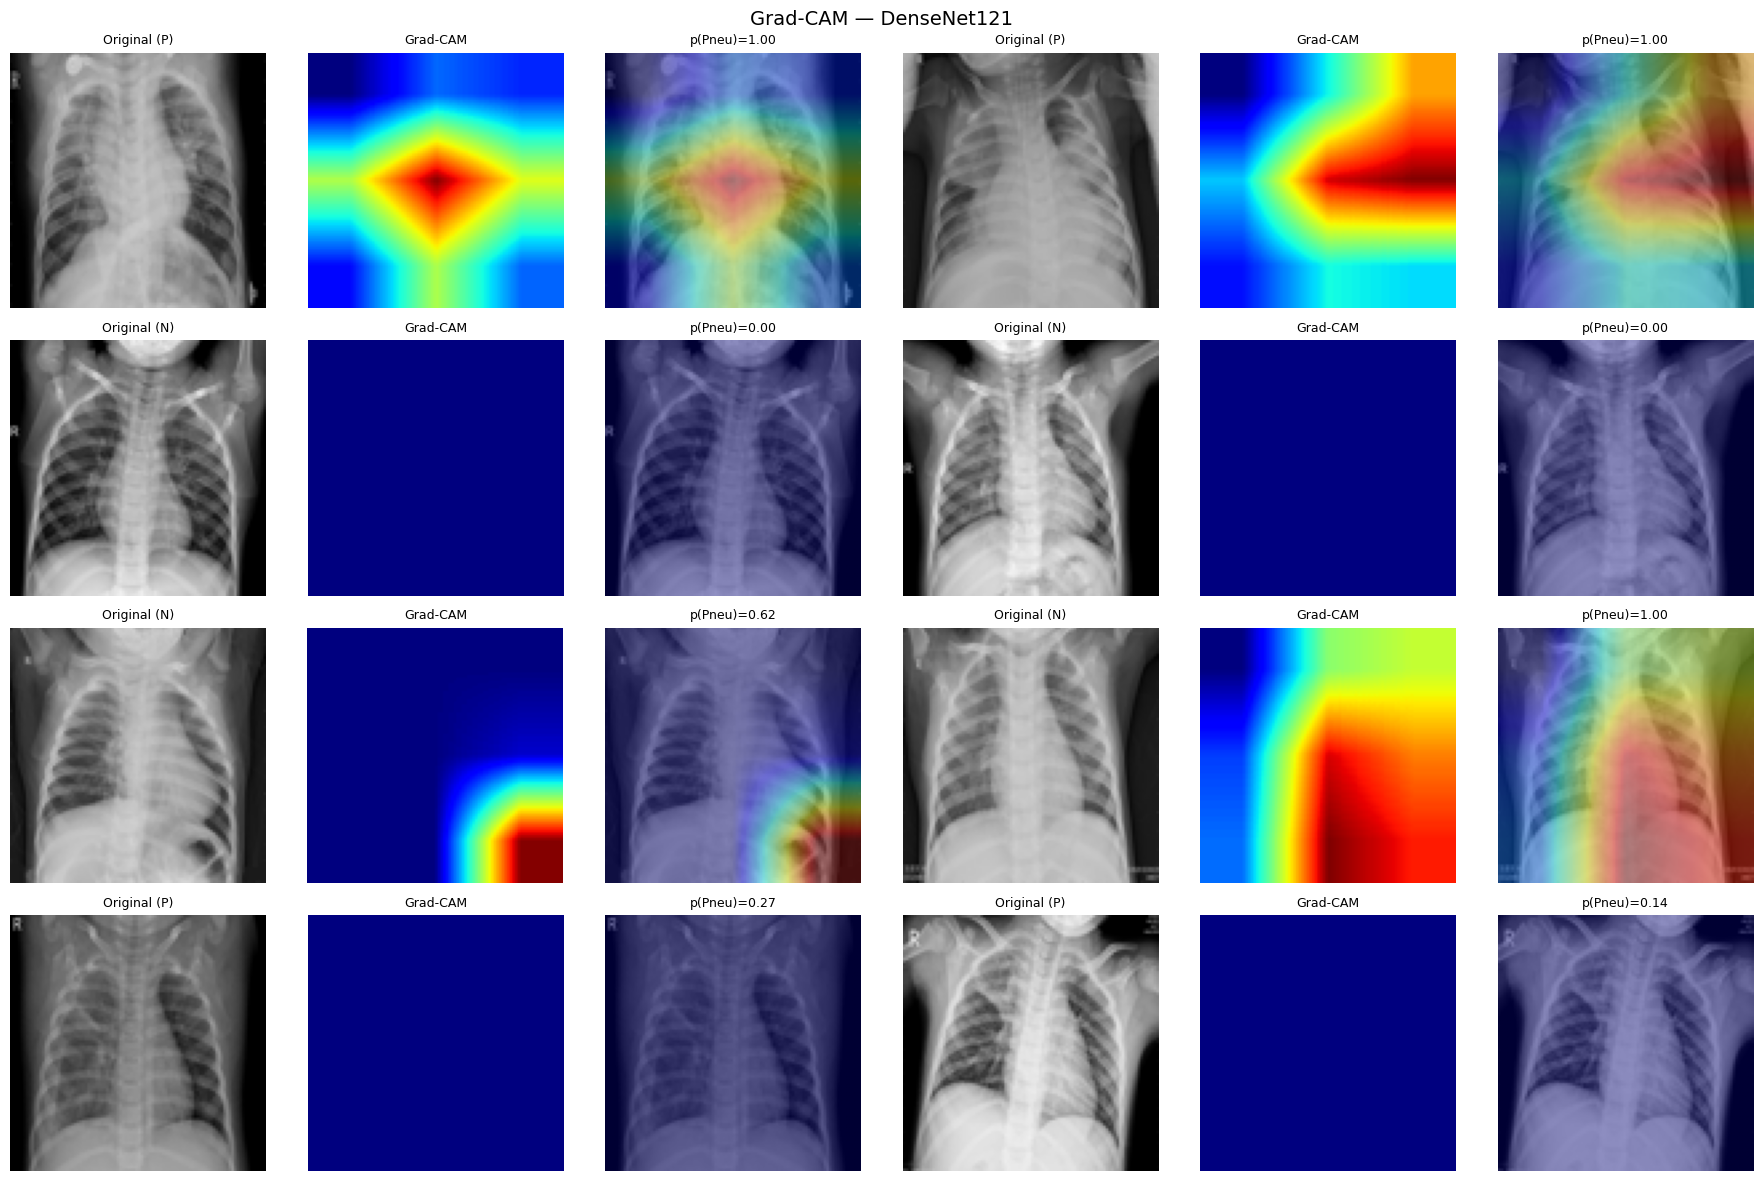

In [25]:
# grad cam grid
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
row_titles = ["True Positive", "True Negative", "False Positive", "False Negative"]

for row, cat in enumerate(row_titles):
    idxs = samples[cat]
    if len(idxs) == 0:
        for col in range(6):
            axes[row, col].axis("off")
        axes[row, 0].text(0.5, 0.5, f"{cat}\n(no examples)",
                          ha="center", va="center", fontsize=11)
        continue

    for col_block, i in enumerate(idxs[:2]):
        img_tensor, label, path = val_ds[i]
        inp = img_tensor.unsqueeze(0).to(DEVICE)
        cam, probs = gradcam.generate(inp, class_idx=1)

        pil = Image.open(path).convert("L")
        orig, heat, over = overlay_cam(pil, cam)

        base = col_block * 3
        axes[row, base    ].imshow(orig); axes[row, base    ].set_title(f"Original ({'P' if label else 'N'})", fontsize=9)
        axes[row, base + 1].imshow(heat); axes[row, base + 1].set_title("Grad-CAM", fontsize=9)
        axes[row, base + 2].imshow(over); axes[row, base + 2].set_title(f"p(Pneu)={probs[1]:.2f}", fontsize=9)

        for c in range(3):
            axes[row, base + c].axis("off")

plt.suptitle(f"Grad-CAM — DenseNet121", fontsize=14)
plt.tight_layout()
plt.savefig(GRADCAM_DIR / "05_gradcam_grid.png", dpi=150)
plt.show()

In [26]:
# save individual overlays
saved = []
for cat, idxs in samples.items():
    for rank, i in enumerate(idxs[:2]):
        img_tensor, label, path = val_ds[i]
        inp = img_tensor.unsqueeze(0).to(DEVICE)
        cam, probs = gradcam.generate(inp, class_idx=1)

        pil = Image.open(path).convert("L")
        _, _, over = overlay_cam(pil, cam)

        fname = GRADCAM_DIR / f"{cat.replace(' ','_').lower()}_{rank+1}.png"
        plt.imsave(fname, over)
        saved.append(str(fname))

print(f"Saved {len(saved)} overlays to {GRADCAM_DIR}")
for s in saved:
    print("  ", s)

Saved 8 overlays to C:\Users\Admin\lungprints\results\figures\gradcam
   C:\Users\Admin\lungprints\results\figures\gradcam\true_positive_1.png
   C:\Users\Admin\lungprints\results\figures\gradcam\true_positive_2.png
   C:\Users\Admin\lungprints\results\figures\gradcam\true_negative_1.png
   C:\Users\Admin\lungprints\results\figures\gradcam\true_negative_2.png
   C:\Users\Admin\lungprints\results\figures\gradcam\false_positive_1.png
   C:\Users\Admin\lungprints\results\figures\gradcam\false_positive_2.png
   C:\Users\Admin\lungprints\results\figures\gradcam\false_negative_1.png
   C:\Users\Admin\lungprints\results\figures\gradcam\false_negative_2.png


In [27]:
# interpretation notes
vm = ckpt["val_metrics"]
interpretation = f"""
Grad-CAM interpretation notes — model: DenseNet121

What to look for:
- True Positives:  heat concentrates on lung fields (mid-left and mid-right).
- True Negatives:  heat is diffuse or focuses on non-lung tissue.
- False Positives: heat often lands on ribs, borders, or medical devices
                   -> a sign of spurious correlation.
- False Negatives: heat is weak or misplaced -> the model missed the lesion.

Caveats:
- Grad-CAM shows which regions influenced the model's output.
- It does NOT prove that a highlighted region is the pneumonia lesion.
- It is a research/interpretability tool, not a clinical explanation.
- Different architectures may highlight different regions for the same image.

Model:              DenseNet121
Best epoch:         {ckpt['epoch']}
Validation F1:      {vm['f1']:.4f}
Validation recall:  {vm['recall']:.4f}
Validation ROC-AUC: {vm['roc_auc']:.4f}
Validation PR-AUC:  {vm['pr_auc']:.4f}
"""
print(interpretation)

with open(RES_DIR / "05_gradcam_notes.txt", "w") as f:
    f.write(interpretation)
print("Saved:", RES_DIR / "05_gradcam_notes.txt")


Grad-CAM interpretation notes — model: DenseNet121

What to look for:
- True Positives:  heat concentrates on lung fields (mid-left and mid-right).
- True Negatives:  heat is diffuse or focuses on non-lung tissue.
- False Positives: heat often lands on ribs, borders, or medical devices
                   -> a sign of spurious correlation.
- False Negatives: heat is weak or misplaced -> the model missed the lesion.

Caveats:
- Grad-CAM shows which regions influenced the model's output.
- It does NOT prove that a highlighted region is the pneumonia lesion.
- It is a research/interpretability tool, not a clinical explanation.
- Different architectures may highlight different regions for the same image.

Model:              DenseNet121
Best epoch:         11
Validation F1:      0.9844
Validation recall:  0.9768
Validation ROC-AUC: 0.9972
Validation PR-AUC:  0.9990

Saved: C:\Users\Admin\lungprints\results\05_gradcam_notes.txt


In [28]:
# save
gradcam_meta = {
    "model": "densenet121",
    "img_size": IMG_SIZE,
    "samples": {k: [int(i) for i in v] for k, v in samples.items()},
    "val_metrics": {k: float(v) for k, v in ckpt["val_metrics"].items()},
    "best_epoch": int(ckpt["epoch"]),
    "note": "Grad-CAM is an interpretability tool, not a clinical explanation.",
}
with open(RES_DIR / "05_gradcam_meta.json", "w") as f:
    json.dump(gradcam_meta, f, indent=2)
print("Saved:", RES_DIR / "05_gradcam_meta.json")

Saved: C:\Users\Admin\lungprints\results\05_gradcam_meta.json


In [ ]:
# ============================================================
# FEATURE FOCUS + EXPLAINABILITY NOTES
# ============================================================

explainability = f"""
================================================================================
EXPLAINABILITY — GRAD-CAM (Model: DenseNet121)
================================================================================

WHICH AREAS DID THE MODEL FOCUS ON?
-----------------------------------
- True Positives:  heat concentrated on lung fields (mid-left and mid-right
                   of the chest). This matches radiological expectation.
- True Negatives:  heat was diffuse or concentrated on non-lung tissue
                   (ribs, borders), consistent with detecting ABSENCE of
                   pneumonia.
- False Positives: heat often landed on ribs, borders, or medical devices
                   -> spurious correlation, not pathology.
- False Negatives: heat was weak or misplaced; the model missed the lesion,
                   likely because it was small or low-contrast at 96x96.

WHICH FEATURES DID THE MODEL LEARN?
-----------------------------------
1. Bilateral lung opacity patterns (bright regions in lung fields).
2. Loss of normal lung lucency (dark lung fields become lighter).
3. Symmetry/asymmetry between the two lungs.
4. Secondary cues from ribs and mediastinum.

WHAT GRAD-CAM DOES NOT SHOW
---------------------------
- It does NOT prove the highlighted region IS the pneumonia lesion.
- It does NOT provide a clinical diagnosis.
- It does NOT explain WHY the model made its decision — only WHERE it
  focused.
- It is model-dependent: different architectures highlight different regions.
- At 96x96 resolution, small lesions may be missed by the heatmap.

RECOMMENDED USE
---------------
Grad-CAM is a debugging and sanity-checking tool, not a clinical
explanation. It helps verify the model is looking at the right anatomical
regions and not cheating with dataset artifacts.
"""
print(explainability)

with open(RES_DIR / "05_explainability.txt", "w", encoding="utf-8") as f:
    f.write(explainability)
print("Saved:", RES_DIR / "05_explainability.txt")